In [1]:
# file: scripts/lgbm_from_feature_csvs.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, adjusted_rand_score, v_measure_score
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
FILES = {
    "HVG-Harmony":           "features_hvg_harmony.csv",
    "Markers-Harmony":       "features_markers_harmony.csv",
    "Combined (raw concat)": "features_combined.csv",
    "Combined (z-score)":    "features_combined_z-score.csv",
}
LABEL_COL = "cell_type"
N_SPLITS  = 5
SEED      = 42
LGB_PARAMS = dict(
    objective="multiclass",
    learning_rate=0.02,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,             # with early stopping
    subsample=0.6,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
EARLY_STOP_ROUNDS = 50

# ---------------- Utils ----------------
def load_features(path: str, label_col: str = LABEL_COL) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Load cells×features CSV. y from label_col; X = all numeric cols (including pct_counts_mt & embeddings)."""
    df = pd.read_csv(path, index_col=0)
    if label_col not in df.columns:
        raise ValueError(f"{os.path.basename(path)} 缺少標籤欄位 '{label_col}'")
    y_str = df[label_col].astype(str).values

    # keep only numeric columns for features
    num_df = df.select_dtypes(include=[np.number]).copy()

    # drop columns with all NaN or zero variance
    nunique = num_df.nunique(dropna=True)
    keep = (nunique > 1)
    X_df = num_df.loc[:, keep]
    dropped = num_df.columns[~keep].tolist()

    # LightGBM 可處理 NaN；這裡不強制填補，但若全列都是 NaN 會在前面被丟
    X = X_df.to_numpy(dtype=float)
    feature_names = X_df.columns.tolist()

    if X.shape[1] == 0:
        raise ValueError(f"{os.path.basename(path)} 沒有可用的數值特徵（可能都為常數或缺失）。")

    if dropped:
        print(f"[Info] {os.path.basename(path)} 移除 {len(dropped)} 個常數特徵。")

    return X, y_str, feature_names

def cv_eval_lgbm(X: np.ndarray, y_str: np.ndarray) -> pd.DataFrame:
    """5-fold stratified CV with early stopping. Return per-fold and mean metrics."""
    le = LabelEncoder().fit(y_str)
    y = le.transform(y_str)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        clf = lgb.LGBMClassifier(num_class=len(le.classes_), **LGB_PARAMS)
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it = clf.best_iteration_ or LGB_PARAMS["n_estimators"]
        y_hat = clf.predict(X_va, num_iteration=best_it)

        acc = accuracy_score(y_va, y_hat)
        f1m = f1_score(y_va, y_hat, average="macro")
        ari = adjusted_rand_score(y_va, y_hat)
        vme = v_measure_score(y_va, y_hat)
        sc  = 0.5 * (ari + vme)

        rows.append({
            "fold": fold,
            "n_train": int(len(tr_idx)),
            "n_val": int(len(va_idx)),
            "best_iter": int(best_it),
            "ACC": float(acc),
            "F1_macro": float(f1m),
            "ARI": float(ari),
            "V": float(vme),
            "Score(0.5*ARI+0.5*V)": float(sc),
        })

    df = pd.DataFrame(rows)
    df.loc["mean"] = {
        "fold": "mean",
        "n_train": int(np.mean(df["n_train"])),
        "n_val": int(np.mean(df["n_val"])),
        "best_iter": int(np.round(df["best_iter"].mean())),
        "ACC": df["ACC"].mean(),
        "F1_macro": df["F1_macro"].mean(),
        "ARI": df["ARI"].mean(),
        "V": df["V"].mean(),
        "Score(0.5*ARI+0.5*V)": df["Score(0.5*ARI+0.5*V)"].mean(),
    }
    return df

# ---------------- Run for each file ----------------
available: Dict[str, str] = {}
for name, fname in FILES.items():
    path = os.path.join(IN_DIR, fname)
    if os.path.exists(path):
        available[name] = path

if not available:
    raise FileNotFoundError(f"找不到任何特徵檔於 {IN_DIR}：{list(FILES.values())}")

summary_rows = []
for name, path in available.items():
    print(f"\n=== LGBM CV on: {name} ===")
    X, y_str, feat_names = load_features(path)
    print(f"Loaded: {os.path.basename(path)} | X={X.shape} | classes={len(np.unique(y_str))} | features={len(feat_names)}")
    df = cv_eval_lgbm(X, y_str)
    print(df.to_string(index=False))

    # keep means for summary
    mean_row = df.loc["mean"]
    summary_rows.append({
        "FeatureSet": name,
        "ACC": mean_row["ACC"],
        "F1_macro": mean_row["F1_macro"],
        "ARI": mean_row["ARI"],
        "V": mean_row["V"],
        "Score": mean_row["Score(0.5*ARI+0.5*V)"],
        "best_iter_mean": int(mean_row["best_iter"]),
        "n_val_mean": int(mean_row["n_val"]),
    })

# Summary across sets
summary = pd.DataFrame(summary_rows).sort_values("Score", ascending=False)
print("\n=== Summary (sorted by Score=0.5*ARI+0.5*V) ===")
print(summary.to_string(index=False))



=== LGBM CV on: HVG-Harmony ===


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\2828703065.py:39: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


Loaded: features_hvg_harmony.csv | X=(50990, 51) | classes=10 | features=51
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13005
[LightGBM] [Info] Number of data points in the train set: 40792, number of used features: 51
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.487951
[LightGBM] [Info] Start training from score -4.444541
[LightGBM] [Info] Start training from score -2.975637
[LightGBM] [Info] Start training from score -3.825020
[LightGBM] [Info] Start training from score -3.02035

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010026 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13005
[LightGBM] [Info] Number of data points in the train set: 40792, number of used features: 51
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.488246
[LightGBM] [Info] Start training from score -4.444541
[LightGBM] [Info] Start training from score -2.975157
[LightGBM] [Info] Start training from score -3.826144
[Light

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022972 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 40792, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.487951
[LightGBM] [Info] Start training from score -4.444541
[LightGBM] [Info] Start training from score -2.975157
[LightGBM] [Info] Start training from score -3.825020
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 40792, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.487951
[LightGBM] [Info] Start training from score -4.442455
[LightGBM] [Info] Start training from score -2.975637
[LightGBM] [Info] Start training from score -3.825020
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
fold  n_train  n_val  best_iter      ACC  F1_macro      ARI        V  Score(0.5*ARI+0.5*V)
   1    40792  10198        412 0.849382  0.776570 0.637354 0.667417              0.652386
   2    40792  10198        408 0.850167  0.772569 0.640351 0.664319              0.652335
   3    40792  10198        450 0.850265  0.789256 0.634961 0.669207              0.652084
   4    40792  10198        419 0.857129  0.783986 0.651845 0.677809              0.664827
   5    40792  10198        401 0.845754  0.777945 0.622224 0.666385              0.644304
mean    40792  10198        418 0.850539  0.780065 0.637347 0.669027              0.653187

=== Summary (sorted by Score=0.5*ARI+0.5*V) ===
           FeatureSet      ACC  F1_macro      ARI        V    Score  best_iter_mean  n_val_mean
Combined (raw concat) 0.851049  0.777999 0.639573 0.669253 0.654413             433       10198


In [7]:
# --- Inspect percentage of cell_type in features_combined_z-score.csv ---
import os
import pandas as pd
import numpy as np

IN_DIR = "./outputs_features_csv"
FNAME  = "features_combined_z-score.csv"
PATH   = os.path.join(IN_DIR, FNAME)

if not os.path.exists(PATH):
    raise FileNotFoundError(f"Not found: {PATH}")

df = pd.read_csv(PATH, index_col=0)

if "cell_type" not in df.columns:
    raise ValueError(f"Column 'cell_type' not found in {FNAME}. Available: {list(df.columns)[:12]}...")

# clean label strings to avoid 'nan' text
ct = df["cell_type"].astype(str).str.strip()
ct = ct.mask(ct.str.lower().isin(["", "nan"]), np.nan)  # treat '' and 'nan' as missing

def as_percent_series(s: pd.Series) -> pd.Series:
    """why: show percent instead of count; drop NaN before computing."""
    s = s.dropna()
    return (s.value_counts(normalize=True).sort_index() * 100.0).round(2)

# Overall percentages
pct_overall = as_percent_series(ct)
print("=== Percentage of cell_type (overall, %) ===")
print(pct_overall.to_string())

# If 'set' exists, also split by train/test and show percentages
if "set" in df.columns:
    sets = df["set"].astype(str).unique().tolist()
    for s in sorted(sets):
        mask = df["set"].astype(str) == s
        pct_s = as_percent_series(ct[mask])
        print(f"\n=== Percentage of cell_type in set='{s}' (%, within-set) ===")
        if pct_s.empty:
            print("[no labeled rows]")
        else:
            print(pct_s.to_string())
else:
    print("\n[Info] Column 'set' not found; only overall percentages printed.")


=== Percentage of cell_type (overall, %) ===
cell_type
B                13.08
Endothelial       1.85
Fibroblast        8.04
Mast              3.43
Myeloid           7.68
Myofibroblast     2.22
NK                5.90
Plasmablast       6.28
T                51.51

[Info] Column 'set' not found; only overall percentages printed.


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\2991244496.py:13: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH, index_col=0)


In [6]:
# file: scripts/lgbm_from_feature_csvs_imbalanced.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
FILES = {
    "Combined (raw concat)": "features_combined.csv",
    "Combined (z-score)":    "features_combined_z-score.csv",

}
LABEL_COL = "cell_type"
OPTIONAL_GROUP_COLS = ["Patient", "Sample", "set"]  # 依序嘗試
N_SPLITS  = 5
SEED      = 42

# 不平衡處理參數
USE_SAMPLE_WEIGHTS = True         # why: 依類別頻率做反比加權
WEIGHT_SMOOTH_ALPHA = 0.0         # >0 可平滑：count+alpha
WEIGHT_MAX = 5.0                  # 限制極端權重；None 表示不裁切

# ---------------- Utils ----------------
def load_features(path: str, label_col: str = LABEL_COL,
                  optional_group_cols: List[str] = OPTIONAL_GROUP_COLS
                 ) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], List[str]]:
    df = pd.read_csv(path, index_col=0)

    if label_col not in df.columns:
        raise ValueError(f"{os.path.basename(path)} 缺少標籤欄位 '{label_col}'")

    # ---- 先濾掉沒有 label 的列（通常是 test rows）----
    lbl = df[label_col]
    valid_mask = (
        lbl.notna()
        & lbl.astype(str).str.strip().ne("")           # 空字串
        & lbl.astype(str).str.lower().ne("nan")        # 文字 'nan'
    )
    n_before, n_after = len(df), int(valid_mask.sum())
    if n_after == 0:
        raise ValueError(f"{os.path.basename(path)} 內沒有任何帶標籤的資料列。")
    if n_after < n_before:
        print(f"[Info] {os.path.basename(path)} 移除無標籤列（可能為 test）：{n_before - n_after} / {n_before}")

    df = df.loc[valid_mask].copy()

    # groups: 盡量用 Patient，其次 Sample，再不行用 set；若都沒有，返回 None
    group = None
    for c in optional_group_cols:
        if c in df.columns:
            group = df[c].astype(str).values
            break

    y_str = df[label_col].astype(str).values

    # features = 所有數值欄（含 pct_counts_mt 與 embeddings）
    X_df = df.select_dtypes(include=[np.number]).copy()

    # 丟掉全 NaN 或常數欄
    nunique = X_df.nunique(dropna=True)
    keep = (nunique > 1)
    if keep.sum() == 0:
        raise ValueError(f"{os.path.basename(path)} 沒有可用的數值特徵（全為常數或缺失）。")
    X_df = X_df.loc[:, keep]

    X = X_df.to_numpy(dtype=float)
    feat_names = X_df.columns.tolist()
    return X, y_str, group, feat_names


def make_sample_weights(y_str: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    """why: 反比於類別頻率，防止少數類別被忽略。"""
    vc = pd.Series(y_str).value_counts()
    K = float(vc.shape[0])
    N = float(len(y_str))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_str], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def cv_eval_lgbm(X: np.ndarray, y_str: np.ndarray, groups: Optional[np.ndarray]) -> pd.DataFrame:
    le = LabelEncoder().fit(y_str)
    y = le.transform(y_str)

    # splitter
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(X, y, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(X, y)

    rows = []
    sw_all = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y, dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        sw_tr = sw_all[tr_idx] if USE_SAMPLE_WEIGHTS else None

        clf = lgb.LGBMClassifier(num_class=len(le.classes_), **LGB_PARAMS)
        clf.fit(
            X_tr, y_tr,
            sample_weight=sw_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it = clf.best_iteration_ or LGB_PARAMS["n_estimators"]
        y_hat = clf.predict(X_va, num_iteration=best_it)

        acc  = accuracy_score(y_va, y_hat)
        bacc = balanced_accuracy_score(y_va, y_hat)
        f1m  = f1_score(y_va, y_hat, average="macro")
        ari  = adjusted_rand_score(y_va, y_hat)
        vme  = v_measure_score(y_va, y_hat)
        score= 0.5 * (ari + vme)

        rows.append({
            "fold": fold,
            "n_train": int(len(tr_idx)),
            "n_val": int(len(va_idx)),
            "best_iter": int(best_it),
            "ACC": float(acc),
            "Balanced_ACC": float(bacc),
            "F1_macro": float(f1m),
            "ARI": float(ari),
            "V": float(vme),
            "Score(0.5*ARI+0.5*V)": float(score),
        })

    df = pd.DataFrame(rows)
    df.loc["mean"] = {
        "fold": "mean",
        "n_train": int(np.mean(df["n_train"])),
        "n_val": int(np.mean(df["n_val"])),
        "best_iter": int(np.round(df["best_iter"].mean())),
        "ACC": df["ACC"].mean(),
        "Balanced_ACC": df["Balanced_ACC"].mean(),
        "F1_macro": df["F1_macro"].mean(),
        "ARI": df["ARI"].mean(),
        "V": df["V"].mean(),
        "Score(0.5*ARI+0.5*V)": df["Score(0.5*ARI+0.5*V)"].mean(),
    }
    return df

# ---------------- Run for each feature file ----------------
available: Dict[str, str] = {}
for name, fname in FILES.items():
    path = os.path.join(IN_DIR, fname)
    if os.path.exists(path):
        available[name] = path

if not available:
    raise FileNotFoundError(f"找不到任何特徵檔於 {IN_DIR}：{list(FILES.values())}")

summary_rows = []
for name, path in available.items():
    print(f"\n=== LGBM CV on: {name} ===")
    X, y_str, groups, feat_names = load_features(path)
    print(f"Loaded: {os.path.basename(path)} | X={X.shape} | classes={len(np.unique(y_str))} | features={len(feat_names)}"
          + (f" | groups={groups.dtype.name}" if groups is not None else " | groups=None"))
    df = cv_eval_lgbm(X, y_str, groups)
    print(df.to_string(index=False))

    mean_row = df.loc["mean"]
    summary_rows.append({
        "FeatureSet": name,
        "ACC": mean_row["ACC"],
        "Balanced_ACC": mean_row["Balanced_ACC"],
        "F1_macro": mean_row["F1_macro"],
        "ARI": mean_row["ARI"],
        "V": mean_row["V"],
        "Score": mean_row["Score(0.5*ARI+0.5*V)"],
        "best_iter_mean": int(mean_row["best_iter"]),
    })

summary = pd.DataFrame(summary_rows).sort_values("Score", ascending=False)
print("\n=== Summary (sorted by Score=0.5*ARI+0.5*V) ===")
print(summary.to_string(index=False))



=== LGBM CV on: Combined (raw concat) ===


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\3382140004.py:36: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[Info] features_combined.csv 移除無標籤列（可能為 test）：18616 / 50990
Loaded: features_combined.csv | X=(32374, 101) | classes=9 | features=101 | groups=None
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011009 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -2.362116
[LightGBM] [Info] Start training from score -2.178800
[LightGBM] [Info] Start training 

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178528
[LightGBM] [Info] Start training from score -2.361896
[LightGBM] [Info] Start training from score -2.178099
[LightGBM] [Info] Start training from score -2.178966
[Ligh

...

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178267
[LightGBM] [Info] Start training from score -2.361930
[LightGBM] [Info] Start training from score -2.178134
[LightGBM] [Info] Start training from score -2.177876
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
# file: scripts/lgbm_two_stage_mask_vs_unmask.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
FILES = {
    "Combined (raw concat)": "features_combined.csv",
    "Combined (z-score)":    "features_combined_z-score.csv",
}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample", "set"]
N_SPLITS  = 5
SEED      = 42

# LightGBM
EARLY_STOP_ROUNDS = 50  # <= updated
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Imbalance controls
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# Threshold grid: 0.1 ~ 0.9 step 0.1  <= updated
THRESH_GRID = np.arange(0.1, 1.0, 0.1)

# ---------------- Utils ----------------
def load_features(path: str, label_col: str = LABEL_COL,
                  optional_group_cols: List[str] = OPTIONAL_GROUP_COLS
                 ) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], List[str]]:
    df = pd.read_csv(path, index_col=0)
    if label_col not in df.columns:
        raise ValueError(f"{os.path.basename(path)} 缺少標籤欄位 '{label_col}'")
    lbl = df[label_col]
    valid_mask = lbl.notna() & lbl.astype(str).str.strip().ne("") & lbl.astype(str).str.lower().ne("nan")
    if valid_mask.sum() == 0:
        raise ValueError(f"{os.path.basename(path)} 內沒有任何帶標籤的資料列。")
    if valid_mask.sum() < len(df):
        print(f"[Info] {os.path.basename(path)} 移除無標籤列：{len(df) - int(valid_mask.sum())} / {len(df)}")
    df = df.loc[valid_mask].copy()

    group = None
    for c in optional_group_cols:
        if c in df.columns:
            group = df[c].astype(str).values
            break

    y_str = df[label_col].astype(str).values
    X_df = df.select_dtypes(include=[np.number]).copy()
    nunique = X_df.nunique(dropna=True)
    keep = (nunique > 1)
    if keep.sum() == 0:
        raise ValueError(f"{os.path.basename(path)} 沒有可用的數值特徵。")
    X_df = X_df.loc[:, keep]

    X = X_df.to_numpy(dtype=float)
    feat_names = X_df.columns.tolist()
    return X, y_str, group, feat_names

def make_sample_weights(y_str: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    vc = pd.Series(y_str).value_counts()
    K = float(vc.shape[0]); N = float(len(y_str))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_str], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

def pick_best_threshold(p_pos: np.ndarray, y_true_bin: np.ndarray, grid: np.ndarray) -> Tuple[float, float]:
    best_thr, best_acc = 0.5, -1.0
    for t in grid:
        pred = (p_pos >= t).astype(int)
        acc = accuracy_score(y_true_bin, pred)
        if acc > best_acc:
            best_acc, best_thr = acc, t
    return float(best_thr), float(best_acc)

def run_two_stage_cv(X: np.ndarray, y_str: np.ndarray, groups: Optional[np.ndarray]) -> pd.DataFrame:
    le_full = LabelEncoder().fit(y_str)
    y_multi = le_full.transform(y_str)
    y_bin = (y_str == POS_LABEL).astype(int)

    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(X, y_multi, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(X, y_multi)

    sw_multi = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y_multi, dtype=float)
    sw_bin   = make_sample_weights(np.where(y_bin==1, POS_LABEL, "nonT")) if USE_SAMPLE_WEIGHTS else np.ones_like(y_bin, dtype=float)

    rows = []
    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr_multi, y_va_multi = y_multi[tr_idx], y_multi[va_idx]
        y_tr_bin,   y_va_bin   = y_bin[tr_idx],   y_bin[va_idx]
        sw_tr_multi = sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None
        sw_tr_bin   = sw_bin[tr_idx]   if USE_SAMPLE_WEIGHTS else None

        # Stage-1: Binary
        bin_clf = lgb.LGBMClassifier(**{**LGB_PARAMS_BIN})
        bin_clf.fit(
            X_tr, y_tr_bin,
            sample_weight=sw_tr_bin,
            eval_set=[(X_va, y_va_bin)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
        p_pos = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
        thr_star, acc_bin = pick_best_threshold(p_pos, y_va_bin, THRESH_GRID)

        # Stage-2: Multiclass
        K = len(le_full.classes_)
        multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        multi_clf.fit(
            X_tr, y_tr_multi,
            sample_weight=sw_tr_multi,
            eval_set=[(X_va, y_va_multi)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]

        # baseline
        yhat_multi = multi_clf.predict(X_va, num_iteration=best_it_multi)

        # masked
        mask_is_T = (p_pos >= thr_star)
        yhat_mask = yhat_multi.copy()
        if POS_LABEL in le_full.classes_:
            t_idx = int(np.where(le_full.classes_ == POS_LABEL)[0][0])
            yhat_mask[mask_is_T] = t_idx

        m_base = metrics_all(y_va_multi, yhat_multi)
        m_mask = metrics_all(y_va_multi, yhat_mask)

        rows.append({
            "fold": fold,
            "val_n": int(len(va_idx)),
            "thr_star": float(thr_star),
            "bin_ACC_at_thr": float(acc_bin),
            "base_ACC": m_base["ACC"],
            "base_BalACC": m_base["Balanced_ACC"],
            "base_F1m": m_base["F1_macro"],
            "base_ARI": m_base["ARI"],
            "base_V":   m_base["V"],
            "base_Score": 0.5*(m_base["ARI"] + m_base["V"]),
            "mask_ACC": m_mask["ACC"],
            "mask_BalACC": m_mask["Balanced_ACC"],
            "mask_F1m": m_mask["F1_macro"],
            "mask_ARI": m_mask["ARI"],
            "mask_V":   m_mask["V"],
            "mask_Score": 0.5*(m_mask["ARI"] + m_mask["V"]),
            "delta_Score": 0.5*(m_mask["ARI"] + m_mask["V"]) - 0.5*(m_base["ARI"] + m_base["V"]),
            "best_iter_bin": int(best_it_bin),
            "best_iter_multi": int(best_it_multi),
        })

    df = pd.DataFrame(rows)
    mean_row = {
        "fold": "mean",
        "val_n": int(np.mean(df["val_n"])),
        "thr_star": float(np.mean(df["thr_star"])),
        "bin_ACC_at_thr": float(np.mean(df["bin_ACC_at_thr"])),
        "base_ACC": float(np.mean(df["base_ACC"])),
        "base_BalACC": float(np.mean(df["base_BalACC"])),
        "base_F1m": float(np.mean(df["base_F1m"])),
        "base_ARI": float(np.mean(df["base_ARI"])),
        "base_V":   float(np.mean(df["base_V"])),
        "base_Score": float(np.mean(df["base_Score"])),
        "mask_ACC": float(np.mean(df["mask_ACC"])),
        "mask_BalACC": float(np.mean(df["mask_BalACC"])),
        "mask_F1m": float(np.mean(df["mask_F1m"])),
        "mask_ARI": float(np.mean(df["mask_ARI"])),
        "mask_V":   float(np.mean(df["mask_V"])),
        "mask_Score": float(np.mean(df["mask_Score"])),
        "delta_Score": float(np.mean(df["delta_Score"])),
        "best_iter_bin": int(np.round(np.mean(df["best_iter_bin"]))),
        "best_iter_multi": int(np.round(np.mean(df["best_iter_multi"]))),
    }
    df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
    return df

# ---------------- Run ----------------
available: Dict[str, str] = {}
for name, fname in FILES.items():
    path = os.path.join(IN_DIR, fname)
    if os.path.exists(path):
        available[name] = path

if not available:
    raise FileNotFoundError(f"找不到任何特徵檔於 {IN_DIR}：{list(FILES.values())}")

for name, path in available.items():
    print(f"\n=== Two-Stage CV on: {name} ===")
    X, y_str, groups, feat_names = load_features(path)
    print(f"Loaded: {os.path.basename(path)} | X={X.shape} | classes={len(np.unique(y_str))} | features={len(feat_names)}"
          + (f" | groups={groups.dtype.name}" if groups is not None else " | groups=None"))

    df = run_two_stage_cv(X, y_str, groups)
    print(df.to_string(index=False))

    last = df.iloc[-1]
    print("\n[Mean]")
    print(pd.DataFrame({
        "binary_thr*":[last["thr_star"]],
        "binary_ACC@thr*":[last["bin_ACC_at_thr"]],
        "UNMASK_Score":[last["base_Score"]],
        "MASK_Score":[last["mask_Score"]],
        "ΔScore":[last["delta_Score"]],
        "UNMASK_ARI":[last["base_ARI"]],
        "MASK_ARI":[last["mask_ARI"]],
        "UNMASK_V":[last["base_V"]],
        "MASK_V":[last["mask_V"]],
    }).round(4).to_string(index=False))



=== Two-Stage CV on: Combined (raw concat) ===


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\2121865412.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[Info] features_combined.csv 移除無標籤列：18616 / 50990
Loaded: features_combined.csv | X=(32374, 101) | classes=9 | features=101 | groups=None
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007469 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -2.362116
[LightGBM] [Info] Start training from score -2.178800
[LightGBM] [Info] Start training from score -2.178062
[Ligh

...

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13341, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499992 -> initscore=-0.000033
[LightGBM] [Info] Start training from score -0.000033


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# file: scripts/lgbm_two_stage_kfold_fixedthr_predict_test.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
OUT_DIR = "./outputs_features_csv"
FILES = {
    "Combined (z-score)":    "features_combined_z-score.csv",
}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample", "set"]
N_SPLITS  = 5
SEED      = 42

# 固定門檻
FIXED_THRESHOLD = 0.55

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Imbalance：樣本權重（不改分布）
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df

def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        # 全部皆視為未標籤
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)

def groups_from(df: pd.DataFrame, cols: List[str]) -> Optional[np.ndarray]:
    for c in cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None

def make_sample_weights(y_like: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    vc = pd.Series(y_like).value_counts()
    K = float(vc.shape[0]); N = float(len(y_like))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_like], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def ensure_prob_matrix(proba, K: int) -> np.ndarray:
    if isinstance(proba, list):
        proba = np.column_stack(proba)
    proba = np.asarray(proba, dtype=float)
    if proba.ndim == 1:
        proba = proba.reshape(-1, 1)
    if proba.shape[1] != K:
        # 部分 LGB 版本在二元時回傳 (n, ) 為正類；這裡不會用到（多類用 K）
        pass
    return proba

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

# ---------------- Per-file run ----------------
def run_kfold_and_predict(df: pd.DataFrame, fname: str) -> None:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows for training.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_str_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    # labeled / unlabeled split for training & predicting
    X_lab = X_all[is_lab.values]
    y_str = y_str_all[is_lab.values]
    idx_lab = idx_all[is_lab.values]

    X_unlab = X_all[is_unlab.values]
    idx_unlab = idx_all[is_unlab.values]

    # encoders & constants
    le = LabelEncoder().fit(y_str)
    classes = le.classes_
    if POS_LABEL not in classes:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not in labels {classes.tolist()}")
    idx_T = int(np.where(classes == POS_LABEL)[0][0])
    y = le.transform(y_str)
    y_bin = (y_str == POS_LABEL).astype(int)
    K = len(classes)

    # groups (only for labeled)
    groups = groups_from(df.loc[idx_lab], OPTIONAL_GROUP_COLS)

    # split
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(X_lab, y, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(X_lab, y)

    # weights
    sw_multi = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y, dtype=float)
    yb_lbl = np.where(y_bin==1, POS_LABEL, "nonT")
    sw_bin  = make_sample_weights(yb_lbl) if USE_SAMPLE_WEIGHTS else np.ones_like(y_bin, dtype=float)

    # storage for fold-wise test predictions
    test_bin_probs: List[np.ndarray] = []   # each (n_test,)
    test_multi_probs: List[np.ndarray] = [] # each (n_test, K)

    # report rows
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        yb_tr, yb_va = y_bin[tr_idx], y_bin[va_idx]

        # ===== Binary =====
        bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
        bin_clf.fit(
            X_tr, yb_tr,
            sample_weight=sw_bin[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(X_va, yb_va)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
        p_va = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
        mask_va = (p_va >= FIXED_THRESHOLD)
        # Multiclass for validation metrics (unmask/mask)
        multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        multi_clf.fit(
            X_tr, y_tr,
            sample_weight=sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
        proba_va = ensure_prob_matrix(multi_clf.predict_proba(X_va, num_iteration=best_it_multi), K)
        yhat_unmask = np.argmax(proba_va, axis=1)
        yhat_mask = yhat_unmask.copy()
        yhat_mask[mask_va] = idx_T

        def pack(y_true, y_pred):
            m = metrics_all(y_true, y_pred); m["Score"] = 0.5*(m["ARI"]+m["V"]); return m
        m_base = pack(y_va, yhat_unmask)
        m_mask = pack(y_va, yhat_mask)

        rows.append({
            "fold": fold,
            "val_n": int(len(va_idx)),
            "thr_fixed": FIXED_THRESHOLD,
            "UNMASK_ACC": m_base["ACC"],
            "UNMASK_BalACC": m_base["Balanced_ACC"],
            "UNMASK_F1m": m_base["F1_macro"],
            "UNMASK_ARI": m_base["ARI"],
            "UNMASK_V":   m_base["V"],
            "UNMASK_Score": m_base["Score"],
            "MASK_ACC": m_mask["ACC"],
            "MASK_BalACC": m_mask["Balanced_ACC"],
            "MASK_F1m": m_mask["F1_macro"],
            "MASK_ARI": m_mask["ARI"],
            "MASK_V":   m_mask["V"],
            "MASK_Score": m_mask["Score"],
            "ΔScore": m_mask["Score"] - m_base["Score"],
            "best_iter_bin": int(best_it_bin),
            "best_iter_multi": int(best_it_multi),
        })

        # ===== Predict ALL test rows in this fold =====
        if len(idx_unlab) > 0:
            p_test = bin_clf.predict_proba(X_unlab, num_iteration=best_it_bin)[:, 1]
            test_bin_probs.append(p_test)

            proba_test = ensure_prob_matrix(multi_clf.predict_proba(X_unlab, num_iteration=best_it_multi), K)
            test_multi_probs.append(proba_test)

    # ---- CV summary ----
    df_cv = pd.DataFrame(rows)
    mean_row = {c:(df_cv[c].mean() if c not in ["fold"] else "mean") for c in df_cv.columns}
    df_cv = pd.concat([df_cv, pd.DataFrame([mean_row])], ignore_index=True)
    print("\n[CV metrics]")
    print(df_cv.to_string(index=False))

    # ---- Fold-mean predictions for TEST ----
    if len(idx_unlab) > 0 and len(test_bin_probs) > 0 and len(test_multi_probs) > 0:
        pT_mean = np.mean(np.vstack(test_bin_probs), axis=0)                 # (n_test,)
        proba_mean = np.mean(np.stack(test_multi_probs, axis=0), axis=0)     # (n_test, K)

        # 最終分類
        yhat_unmask = np.argmax(proba_mean, axis=1)
        yhat_mask = yhat_unmask.copy()
        yhat_mask[pT_mean >= FIXED_THRESHOLD] = idx_T

        # 輸出
        out = pd.DataFrame({"cell_id": idx_unlab, "pT_mean": pT_mean, "thr_used": FIXED_THRESHOLD})
        out["pred_unmask"] = le.inverse_transform(yhat_unmask)
        out["pred_final"]  = le.inverse_transform(yhat_mask)
        for i, cls in enumerate(classes):
            out[f"proba_{cls}"] = proba_mean[:, i]
  
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
    return out

# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Two-Stage KFold w/ fixed threshold (0.55) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_kfold_and_predict(df, fname)



=== Two-Stage KFold w/ fixed threshold (0.55) — Combined (z-score) ===


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\4224473205.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010961 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -2.362116
[LightGBM] [Info] Start training from score -2.178800
[LightGBM] [Info] Start training from score -2.178062
[Ligh

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13341, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:Bo

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[CV metrics]
fold  val_n  thr_fixed  UNMASK_ACC  UNMASK_BalACC  UNMASK_F1m  UNMASK_ARI  UNMASK_V  UNMASK_Score  MASK_ACC  MASK_BalACC  MASK_F1m  MASK_ARI   MASK_V  MASK_Score   ΔScore  best_iter_bin  best_iter_multi
   1 6475.0       0.55    0.939459       0.894180    0.891776    0.874680  0.844502      0.859591  0.943475     0.871804  0.887951  0.884930 0.852371    0.868650 0.009059          165.0             88.0
   2 6475.0       0.55    0.937761       0.893154    0.891813    0.866261  0.840393      0.853327  0.940849     0.866336  0.884722  0.873782 0.845956    0.859869 0.006542          168.0             89.0
   3 6475.0

In [ ]:
# Jupyter cell: build cluster_membership.csv from in-memory `pred` only
import os
import re
import pandas as pd
import scanpy as sc

# ---- Settings ----
TEST_AD_PATH     = "../test_data/test_adata.h5ad"
OUT_CLUSTER_CSV  = "../workflow/outputs/cluster_membership.csv"
STRIP_TEST_SUFFIX = True  # True: 比對前移除 cell_id 結尾的 "-test"

# ---- Guards ----
if "pred" not in globals() or not isinstance(pred, pd.DataFrame):
    raise RuntimeError("需要記憶體中的 DataFrame `pred`（含 columns: cell_id, pred_final）。")

need_cols = {"cell_id", "pred_final"}
missing = need_cols - set(pred.columns)
if missing:
    raise ValueError(f"`pred` 缺少欄位: {missing}. 需要 {need_cols}")

df_pred = pred[list(need_cols)].copy()

# ---- Normalize cell_id for matching ----
if STRIP_TEST_SUFFIX:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str).str.replace(r"-test$", "", regex=True)
else:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str)

# ---- Load test obs order ----
ad_te = sc.read_h5ad(TEST_AD_PATH)
test_order = pd.Index(ad_te.obs_names.astype(str))

# ---- Align & reorder to test order ----
pred_idx = pd.Index(df_pred["cell_id_std"])
common   = test_order.intersection(pred_idx)
if common.empty:
    raise ValueError("pred 的 cell_id 與 test obs_names 沒有交集（檢查 -test 尾碼或命名）。")

df_pred_idxed = (
    df_pred.set_index("cell_id_std", drop=False)
           .loc[common, ["cell_id", "pred_final"]]
           .rename_axis("cell_id_std")
           .reset_index(drop=True)
)
# 使輸出的 cell_id 與 test 完全一致（不帶 '-test'）
df_pred_idxed["cell_id"] = common.values

if len(common) < len(test_order):
    missing_n = len(test_order) - len(common)
    print(f"[Info] test n={len(test_order)}，pred 可對齊 n={len(common)}；缺少 {missing_n} 列未在 pred 中。")

# ---- Build cluster mapping (1..K) ----
labels = df_pred_idxed["pred_final"].astype(str)
uniq_labels = sorted(labels.unique().tolist())

use_order = None
if "TARGET_ORDER" in globals():
    to_set = set(TARGET_ORDER)
    if set(uniq_labels).issubset(to_set):
        use_order = [ct for ct in TARGET_ORDER if ct in uniq_labels]
if use_order is None:
    use_order = uniq_labels  # 字母序穩定

label_to_cluster = {lab: i+1 for i, lab in enumerate(use_order)}  # 1..K

# ---- Compose and save cluster_membership ----
df_cluster = pd.DataFrame({
    "index": df_pred_idxed["cell_id"].values,                           # 與 test obs_names 完全一致的順序
    "cluster": labels.map(label_to_cluster).astype(int).values
})
if df_cluster["index"].duplicated().any():
    raise ValueError("cluster_membership 中 index 出現重複，請檢查。")
if (df_cluster["cluster"] <= 0).any():
    raise ValueError("cluster 必須為正整數（>=1）。")

df_cluster.to_csv(OUT_CLUSTER_CSV, index=True)  # 依你的示例，保留 pandas 行索引
print(f"[OK] wrote cluster_membership: {OUT_CLUSTER_CSV} | rows={len(df_cluster)}")

print("\n(label -> cluster) mapping:")
print(pd.Series(label_to_cluster).to_string())

print("\n[cluster_membership head]")
print(df_cluster.head(10).to_csv(index=True))


[OK] wrote cluster_membership: ../workflow/outputs/cluster_membership.csv | rows=18616

(label -> cluster) mapping:
B                1
Endothelial      2
Fibroblast       3
Mast             4
Myeloid          5
Myofibroblast    6
NK               7
Plasmablast      8
T                9

[cluster_membership head]
,index,cluster
0,AAACCCAAGGAGGCAG-1_5,9
1,AAACCCAAGTTGCGCC-1_5,9
2,AAACCCACACGGATCC-1_5,9
3,AAACCCACATCGGAAG-1_5,9
4,AAACCCAGTGCGAGTA-1_5,9
5,AAACCCATCACGAACT-1_5,9
6,AAACGAAAGTAGAATC-1_5,9
7,AAACGAACAGAGATGC-1_5,9
8,AAACGAATCAAGAATG-1_5,3
9,AAACGAATCCACAAGT-1_5,7



In [15]:
# file: scripts/lgbm_two_stage_kfold_raw_z_mean.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
FILES = {
    "raw":     "features_combined.csv",
    "zscore":  "features_combined_z-score.csv",
}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample", "set"]
N_SPLITS  = 5
SEED      = 42

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Imbalance（用樣本權重；不改變資料分布）
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# Binary threshold grid
THRESH_GRID = np.arange(0.1, 1.0, 0.1)

# ---------------- Utils ----------------
def _load_csv(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found: {path}")
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty dataframe: {path}")
    return df

def _filter_labeled_mask(df: pd.DataFrame, label_col: str) -> pd.Series:
    lbl = df[label_col] if label_col in df.columns else pd.Series(index=df.index, dtype=object)
    return (lbl.notna() &
            lbl.astype(str).str.strip().ne("") &
            lbl.astype(str).str.lower().ne("nan"))

def _numeric_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features after constant-column filtering.")
    Xdf = Xdf.fillna(0.0)  # keep it simple; LGB handles zeros
    return Xdf

def _groups_from(df: pd.DataFrame, optional_cols: List[str]) -> Optional[np.ndarray]:
    for c in optional_cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None

def make_sample_weights(y_like: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    vc = pd.Series(y_like).value_counts()
    K = float(vc.shape[0]); N = float(len(y_like))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_like], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

def pick_best_threshold(p_pos: np.ndarray, y_true_bin: np.ndarray, grid: np.ndarray) -> Tuple[float, float]:
    best_thr, best_acc = 0.5, -1.0
    for t in grid:
        pred = (p_pos >= t).astype(int)
        acc = accuracy_score(y_true_bin, pred)
        if acc > best_acc:
            best_acc, best_thr = acc, t
    return float(best_thr), float(best_acc)

# ---------------- Load & align ----------------
def load_and_align() -> Tuple[np.ndarray, np.ndarray, np.ndarray, Optional[np.ndarray], LabelEncoder]:
    paths = {k: os.path.join(IN_DIR, v) for k, v in FILES.items()}
    dfr = _load_csv(paths["raw"])
    dfz = _load_csv(paths["zscore"])

    mask_r = _filter_labeled_mask(dfr, LABEL_COL)
    mask_z = _filter_labeled_mask(dfz, LABEL_COL)
    idx = dfr.index[mask_r].intersection(dfz.index[mask_z])

    dfr = dfr.loc[idx].copy()
    dfz = dfz.loc[idx].copy()

    y_str = dfr[LABEL_COL].astype(str).values
    le = LabelEncoder().fit(y_str)

    groups = _groups_from(dfr, OPTIONAL_GROUP_COLS)

    Xr = _numeric_matrix(dfr).to_numpy(dtype=float)
    Xz = _numeric_matrix(dfz).to_numpy(dtype=float)
    return Xr, Xz, y_str, groups, le

# ---------------- CV core ----------------
def run_cv(Xr: np.ndarray, Xz: np.ndarray, y_str: np.ndarray, groups: Optional[np.ndarray], le: LabelEncoder) -> pd.DataFrame:
    y = le.transform(y_str)
    classes = le.classes_
    assert POS_LABEL in classes, f"'{POS_LABEL}' not in labels: {classes.tolist()}"
    idx_T = int(np.where(classes == POS_LABEL)[0][0])
    y_bin = (y_str == POS_LABEL).astype(int)

    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(Xr, y, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(Xr, y)

    sw_multi = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y, dtype=float)
    y_bin_lbl = np.where(y_bin==1, POS_LABEL, "nonT")
    sw_bin    = make_sample_weights(y_bin_lbl) if USE_SAMPLE_WEIGHTS else np.ones_like(y_bin, dtype=float)

    rows = []
    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        Xr_tr, Xr_va = Xr[tr_idx], Xr[va_idx]
        Xz_tr, Xz_va = Xz[tr_idx], Xz[va_idx]
        y_tr,  y_va  = y[tr_idx],  y[va_idx]
        yb_tr, yb_va = y_bin[tr_idx], y_bin[va_idx]

        # ===== Binary (raw) =====
        bin_raw = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
        bin_raw.fit(
            Xr_tr, yb_tr,
            sample_weight=sw_bin[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(Xr_va, yb_va)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        pT_raw = bin_raw.predict_proba(Xr_va, num_iteration=bin_raw.best_iteration_ or LGB_PARAMS_BIN["n_estimators"])[:, 1]

        # ===== Binary (zscore) =====
        bin_z = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
        bin_z.fit(
            Xz_tr, yb_tr,
            sample_weight=sw_bin[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(Xz_va, yb_va)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        pT_z = bin_z.predict_proba(Xz_va, num_iteration=bin_z.best_iteration_ or LGB_PARAMS_BIN["n_estimators"])[:, 1]

        # ===== Binary mean & best threshold =====
        pT_mean = (pT_raw + pT_z) / 2.0
        thr_star, acc_bin = pick_best_threshold(pT_mean, yb_va, THRESH_GRID)

        # ===== Multiclass (raw) =====
        K = len(classes)
        m_raw = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        m_raw.fit(
            Xr_tr, y_tr,
            sample_weight=sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(Xr_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        proba_raw = m_raw.predict_proba(Xr_va, num_iteration=m_raw.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"])
        if isinstance(proba_raw, list):  # compatibility
            proba_raw = np.column_stack(proba_raw)

        # ===== Multiclass (zscore) =====
        m_z = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        m_z.fit(
            Xz_tr, y_tr,
            sample_weight=sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(Xz_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        proba_z = m_z.predict_proba(Xz_va, num_iteration=m_z.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"])
        if isinstance(proba_z, list):
            proba_z = np.column_stack(proba_z)

        # ===== Ensemble by mean =====
        proba_mean = (proba_raw + proba_z) / 2.0

        # UNMASK prediction
        yhat_unmask = np.argmax(proba_mean, axis=1)

        # MASK prediction using pT_mean & thr_star
        yhat_mask = yhat_unmask.copy()
        yhat_mask[pT_mean >= thr_star] = idx_T

        # ===== Metrics =====
        def pack(y_true, y_pred):
            m = metrics_all(y_true, y_pred)
            m["Score"] = 0.5*(m["ARI"] + m["V"])
            return m

        m_base = pack(y_va, yhat_unmask)
        m_mask = pack(y_va, yhat_mask)

        rows.append({
            "fold": fold,
            "val_n": int(len(va_idx)),
            "thr_star": float(thr_star),
            "bin_ACC@thr": float(acc_bin),

            "UNMASK_ACC": m_base["ACC"],
            "UNMASK_BalACC": m_base["Balanced_ACC"],
            "UNMASK_F1m": m_base["F1_macro"],
            "UNMASK_ARI": m_base["ARI"],
            "UNMASK_V":   m_base["V"],
            "UNMASK_Score": m_base["Score"],

            "MASK_ACC": m_mask["ACC"],
            "MASK_BalACC": m_mask["Balanced_ACC"],
            "MASK_F1m": m_mask["F1_macro"],
            "MASK_ARI": m_mask["ARI"],
            "MASK_V":   m_mask["V"],
            "MASK_Score": m_mask["Score"],

            "ΔScore": m_mask["Score"] - m_base["Score"],
        })

    df = pd.DataFrame(rows)
    mean_row = {c:(df[c].mean() if c not in ["fold"] else "mean") for c in df.columns}
    df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
    return df

# ---------------- Main ----------------
if __name__ == "__main__":
    X_raw, X_z, y_str, groups, le = load_and_align()
    print(f"[Load] raw:   X={X_raw.shape}, labeled={len(y_str)}")
    print(f"[Load] zscore:X={X_z.shape}, labeled={len(y_str)}")

    df = run_cv(X_raw, X_z, y_str, groups, le)
    print("\n=== Two-Stage K-Fold (per-fold trains 4 models; mean-ensemble) ===")
    print(df.to_string(index=False))

    last = df.iloc[-1]
    print("\n[Mean]")
    print(pd.DataFrame({
        "binary_thr*":[last["thr_star"]],
        "binary_ACC@thr*":[last["bin_ACC@thr"]],
        "UNMASK_Score":[last["UNMASK_Score"]],
        "MASK_Score":[last["MASK_Score"]],
        "ΔScore":[last["ΔScore"]],
        "UNMASK_ARI":[last["UNMASK_ARI"]],
        "MASK_ARI":[last["MASK_ARI"]],
        "UNMASK_V":[last["UNMASK_V"]],
        "MASK_V":[last["MASK_V"]],
    }).round(4).to_string(index=False))


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\1281283335.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)
C:\Users\wani\AppData\Local\Temp\ipykernel_14008\1281283335.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[Load] raw:   X=(32374, 101), labeled=32374
[Load] zscore:X=(32374, 101), labeled=32374
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008573 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\wani\AppData\Local\Temp\ipykernel_14008\1785116702.py:32: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


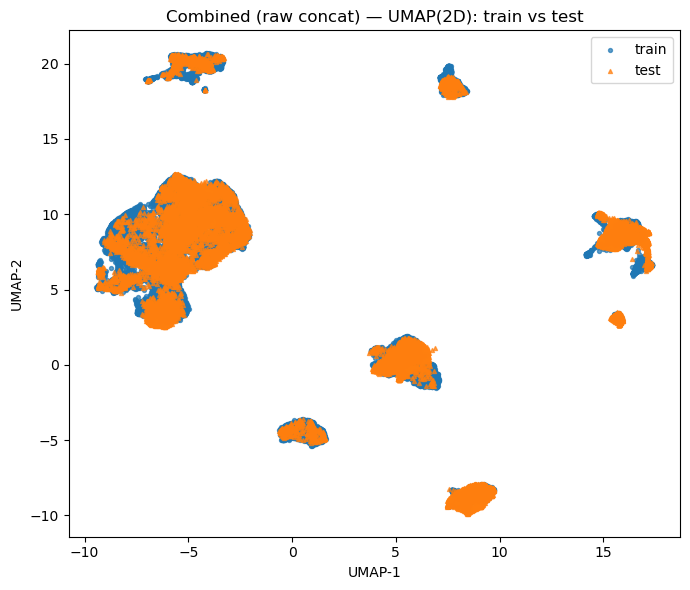

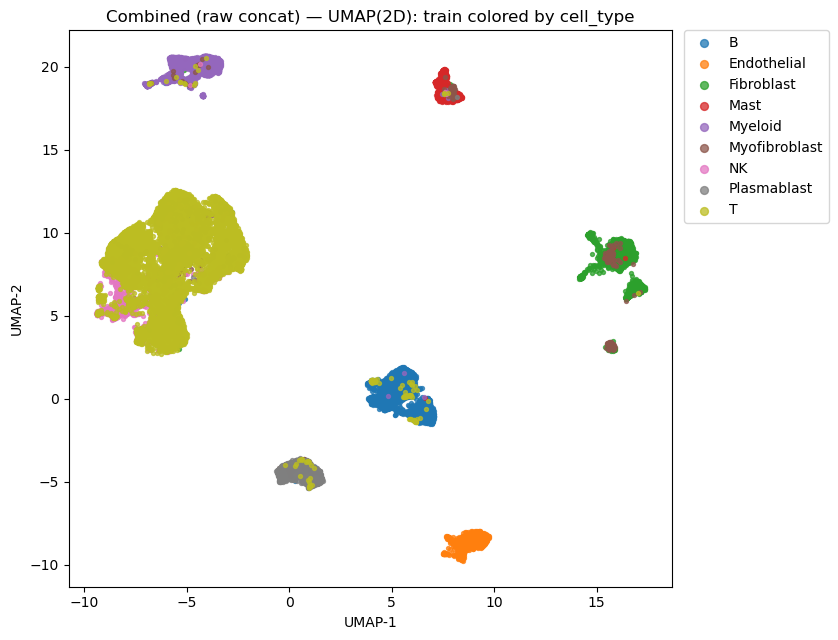

C:\Users\wani\AppData\Local\Temp\ipykernel_14008\1785116702.py:32: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


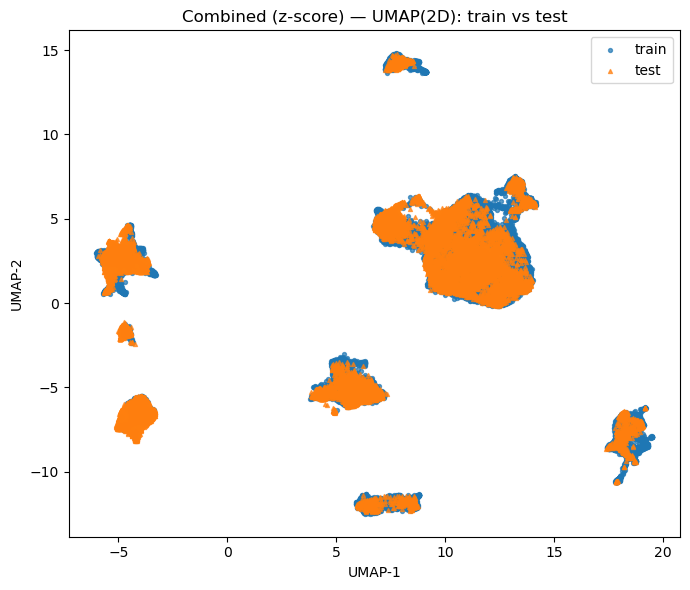

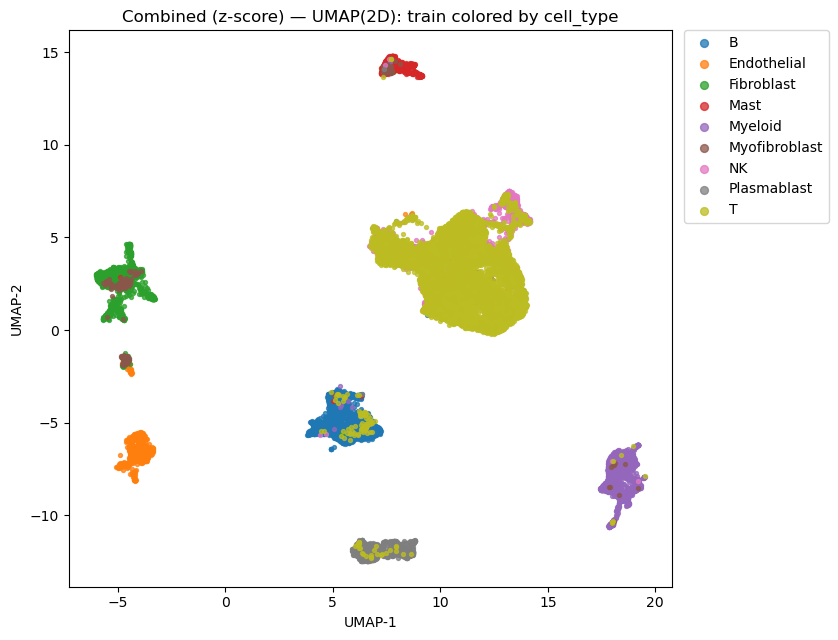

In [13]:
# file: scripts/plot_umap_2d_train_test_and_ct.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# UMAP (pip install umap-learn)
try:
    import umap
except Exception as e:
    raise RuntimeError("需要安裝 umap-learn：pip install umap-learn") from e

IN_DIR = "./outputs_features_csv"
FILES = {
    "Combined (raw concat)": "features_combined.csv",
    "Combined (z-score)":    "features_combined_z-score.csv",
}

LABEL_COL = "cell_type"  # why: 上色/劃分
SET_COL = "set"          # why: train/test 分隔
RANDOM_STATE = 42

# UMAP hyperparams（可依需要調）
N_NEIGHBORS = 15         # why: 小群/局部結構
MIN_DIST    = 0.1
METRIC      = "euclidean"

def load_df(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found: {path}")
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty dataframe: {path}")
    return df

def get_masks(df: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    """why: 以 set 欄為準；不在就用 cell_type 有無視為 train/test。"""
    if SET_COL in df.columns:
        s = df[SET_COL].astype(str).str.lower()
        is_train = s.eq("train")
        is_test  = s.eq("test")
        if not is_train.any() and LABEL_COL in df.columns:
            is_train = df[LABEL_COL].notna()
            is_test  = ~is_train
    else:
        if LABEL_COL in df.columns:
            is_train = df[LABEL_COL].notna()
            is_test  = ~is_train
        else:
            is_train = pd.Series(True, index=df.index)
            is_test  = ~is_train
    return is_train, is_test

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """why: 僅數值欄；丟全 NaN/常數；不做標準化（需求指定）"""
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features after constant-column filtering.")
    # 填 NaN（UMAP 不能吃 NaN）
    Xdf = Xdf.fillna(Xdf.median(numeric_only=True))
    return Xdf

def run_umap(X: np.ndarray) -> np.ndarray:
    """why: 不標準化；直接以原尺度嵌入"""
    reducer = umap.UMAP(
        n_neighbors=N_NEIGHBORS,
        min_dist=MIN_DIST,
        n_components=2,
        metric=METRIC,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=False,
    )
    return reducer.fit_transform(X)

def scatter_train_vs_test(Z: np.ndarray, is_train: pd.Series, title: str):
    plt.figure(figsize=(7, 6))
    plt.scatter(Z[is_train.values, 0], Z[is_train.values, 1], s=8, alpha=0.7, marker='o', label='train')
    if (~is_train).any():
        plt.scatter(Z[~is_train.values, 0], Z[~is_train.values, 1], s=8, alpha=0.7, marker='^', label='test')
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.title(title)
    plt.legend()
    plt.tight_layout(); plt.show()

def scatter_train_by_ct(Z: np.ndarray, df: pd.DataFrame, is_train: pd.Series, title: str):
    if LABEL_COL not in df.columns:
        print("[Info] no 'cell_type' column; skip CT-colored plot.")
        return
    ct = df.loc[is_train, LABEL_COL].astype(str).fillna("NA")
    Zt = Z[is_train.values]
    # 排序：TARGET_ORDER 先，其他字母序
    if 'TARGET_ORDER' in globals() and isinstance(TARGET_ORDER, (list, tuple)):
        known = [c for c in TARGET_ORDER if c in ct.unique()]
        rest = sorted([c for c in ct.unique() if c not in known])
        order = known + rest
    else:
        order = sorted(ct.unique())

    plt.figure(figsize=(8.5, 6.5))
    for k in order:
        m = (ct == k).values
        if not np.any(m): 
            continue
        plt.scatter(Zt[m, 0], Zt[m, 1], s=8, alpha=0.75, label=str(k))
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.title(title)
    plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout(); plt.show()

def main():
    for name, fname in FILES.items():
        path = os.path.join(IN_DIR, fname)
        df = load_df(path)
        is_train, is_test = get_masks(df)
        Xdf = numeric_feature_matrix(df)
        Z = run_umap(Xdf.to_numpy())

        # 1) train vs test
        scatter_train_vs_test(
            Z, is_train,
            title=f"{name} — UMAP(2D): train vs test"
        )
        # 2) train colored by cell_type
        scatter_train_by_ct(
            Z, df, is_train,
            title=f"{name} — UMAP(2D): train colored by cell_type"
        )

if __name__ == "__main__":
    main()
